# 9.15: Lab: Exercises on CNNs

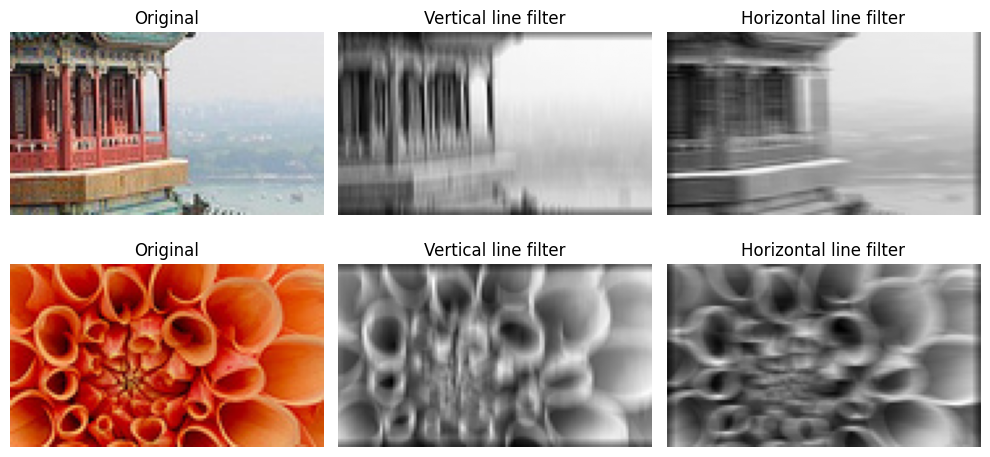

Output shape from a real Conv2D layer: (2, 70, 120, 32)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_images
import tensorflow as tf
from tensorflow import keras

# Load sample images and scale to [0, 1]
images = load_sample_images()["images"]
images = tf.keras.layers.CenterCrop(height=70, width=120)(images)
images = tf.keras.layers.Rescaling(scale=1 / 255)(images)

# Build two 7x7 filters by hand: vertical and horizontal line detectors
filters = np.zeros(shape=(7, 7, 3, 2), dtype=np.float32)
filters[:, 3, :, 0] = 1   # vertical line
filters[3, :, :, 1] = 1   # horizontal line

# Apply them like a convolution layer would
outputs = tf.nn.conv2d(images, filters, strides=1, padding="SAME")

# Visualise
fig, axes = plt.subplots(2, 3, figsize=(10, 5))
for image_idx in range(2):
    axes[image_idx, 0].imshow(images[image_idx])
    axes[image_idx, 0].set_title("Original")
    axes[image_idx, 1].imshow(outputs[image_idx, :, :, 0], cmap="gray")
    axes[image_idx, 1].set_title("Vertical line filter")
    axes[image_idx, 2].imshow(outputs[image_idx, :, :, 1], cmap="gray")
    axes[image_idx, 2].set_title("Horizontal line filter")
    for ax in axes[image_idx]:
        ax.axis("off")
plt.tight_layout()
plt.show()

# A real Conv2D layer does this but LEARNS the filter values
conv_layer = keras.layers.Conv2D(
    filters=32, kernel_size=7, padding="same", activation="relu"
)
learned_outputs = conv_layer(images)
print("Output shape from a real Conv2D layer:", learned_outputs.shape)

In [2]:
"""
Exercise 2
==========
Hands-On Machine Learning (3rd ed.), Chapter 14, around p.461.

Build a simple CNN for Fashion MNIST. This mirrors the architecture used
in the book: a few Conv2D + MaxPooling2D blocks (with increasing numbers
of filters), followed by a Flatten layer and a couple of Dense layers
with Dropout for regularisation.
"""

import tensorflow as tf
from tensorflow import keras

# ---------------------------------------------------------------------
# 1. Load and prepare the Fashion MNIST dataset
# ---------------------------------------------------------------------
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Conv2D expects a channel dimension, so reshape to (N, 28, 28, 1)
X_train_full = X_train_full[..., tf.newaxis].astype("float32") / 255.0
X_test = X_test[..., tf.newaxis].astype("float32") / 255.0

# Hold out a validation set
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# ---------------------------------------------------------------------
# 2. Build a simple CNN
# ---------------------------------------------------------------------
DefaultConv2D = lambda filters, kernel_size=3, **kwargs: keras.layers.Conv2D(
    filters,
    kernel_size=kernel_size,
    padding="same",
    activation="relu",
    kernel_initializer="he_normal",
    **kwargs
)

model = keras.Sequential([
    DefaultConv2D(64, kernel_size=7, input_shape=[28, 28, 1]),
    keras.layers.MaxPooling2D(pool_size=2),

    DefaultConv2D(128),
    DefaultConv2D(128),
    keras.layers.MaxPooling2D(pool_size=2),

    DefaultConv2D(256),
    DefaultConv2D(256),
    keras.layers.MaxPooling2D(pool_size=2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax"),
])

model.summary()

# ---------------------------------------------------------------------
# 3. Compile and train
# ---------------------------------------------------------------------
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="nadam",
    metrics=["accuracy"],
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_valid, y_valid),
)

# ---------------------------------------------------------------------
# 4. Evaluate on the test set
# ---------------------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy (vanilla CNN): {test_acc:.4f}")

model.save("fashion_mnist_cnn.keras")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,413,834 (5.39 MB)

 Trainable params: 1,413,834 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 27s 11ms/step - accuracy: 0.7188 - loss: 0.7919 - val_accuracy: 0.8720 - val_loss: 0.3714
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8572 - loss: 0.4248 - val_accuracy: 0.8970 - val_loss: 0.2946
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8790 - loss: 0.3597 - val_accuracy: 0.9036 - val_loss: 0.2673
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8916 - loss: 0.3193 - val_accuracy: 0.9050 - val_loss: 0.2592
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9022 - loss: 0.2873 - val_accuracy: 0.9112 - val_loss: 0.2547
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9097 - loss: 0.2672 - val_accuracy: 0.9092 - val_loss: 0.2649
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9141 - loss: 0.2530 - val_accuracy: 0.9108 - val_loss: 0.2644
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9189 - loss: 

In [4]:
"""
Exercise 3
==========
Hands-On Machine Learning (3rd ed.), Chapter 14, around p.478.

Build your own ResNet from scratch using a custom ResidualUnit layer,
following the architecture of ResNet-34 described in the book:

    Conv2D(64, 7x7, stride 2) -> BatchNorm -> ReLU -> MaxPool(3x3, stride 2)
    -> a stack of residual units, with the number of filters doubling
       (64 -> 128 -> 256 -> 512) every few units, and the spatial
       resolution being halved each time the number of filters increases
    -> GlobalAveragePooling2D -> Dense(softmax)

This file defines a reusable `build_resnet()` function that exercise 4
imports and trains on Fashion MNIST.
"""

from functools import partial
import tensorflow as tf
from tensorflow import keras

DefaultConv2D = partial(
    keras.layers.Conv2D, kernel_size=3, strides=1,
    padding="same", kernel_initializer="he_normal", use_bias=False,
)


class ResidualUnit(keras.layers.Layer):
    """A single residual unit, as described on p.478 of HOML 3rd ed."""

    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = keras.activations.get(activation)

        # Main path: two conv layers with batch norm
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            keras.layers.BatchNormalization(),
        ]

        # Skip-connection path. If strides > 1, the input has a different
        # shape from the output of the main path, so we need a 1x1 conv
        # to match the shapes before adding them together.
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                keras.layers.BatchNormalization(),
            ]

    def call(self, inputs):
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)

        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)

        return self.activation(Z + skip_Z)


def build_resnet(input_shape=(28, 28, 1), num_classes=10):
    """Builds a smaller ResNet-34-style model.

    The original ResNet-34 was designed for 224x224 ImageNet images and
    has 16 residual units. For a small dataset like Fashion MNIST
    (28x28 grayscale), we scale the architecture down so that it doesn't
    over-aggressively shrink the feature maps to nothing, while keeping
    the same overall design pattern (stem -> residual stacks ->
    global average pooling -> dense classifier).
    """
    model = keras.Sequential()

    # "Stem": initial conv + pooling, like the start of ResNet-34
    model.add(DefaultConv2D(64, kernel_size=7, strides=1,
                             input_shape=input_shape))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Activation("relu"))
    model.add(keras.layers.MaxPooling2D(pool_size=3, strides=2, padding="same"))

    # Residual stacks: filters double, stride 2 used the first time the
    # number of filters changes (this halves the height & width)
    prev_filters = 64
    for filters in [64, 64, 128, 128, 256, 256]:
        strides = 1 if filters == prev_filters else 2
        model.add(ResidualUnit(filters, strides=strides))
        prev_filters = filters

    model.add(keras.layers.GlobalAveragePooling2D())
    model.add(keras.layers.Dense(num_classes, activation="softmax"))
    return model


resnet = build_resnet()
resnet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_6 (ResidualUnit)  │ (None, 14, 14, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_7 (ResidualUnit)  │ (None, 14, 14, 64)     │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_8 (ResidualUnit)  │ (None, 7, 7, 128)      │       230,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_9 (ResidualUnit)  │ (None, 7, 7, 128)      │       295,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_10 (ResidualUnit) │ (None, 4, 4, 256)      │       920,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_unit_11 (ResidualUnit) │ (None, 4, 4, 256)      │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,783,562 (10.62 MB)

 Trainable params: 2,779,082 (10.60 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [6]:
"""
Exercise 4
==========
Train the ResNet built in exercise 3 on Fashion MNIST, and compare its
performance against:
  (a) the "vanilla" CNN from exercise 2, and
  (b) a plain fully-connected DNN with a similar parameter budget.

Note: ResidualUnit and build_resnet() from Exercise 3 must be defined
above (or imported) before running this code.
"""

import tensorflow as tf
from tensorflow import keras

# ---------------------------------------------------------------------
# 1. Load and prepare the Fashion MNIST dataset
# ---------------------------------------------------------------------
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Conv2D expects a channel dimension, so reshape to (N, 28, 28, 1)
X_train_full = X_train_full[..., tf.newaxis].astype("float32") / 255.0
X_test = X_test[..., tf.newaxis].astype("float32") / 255.0

# Hold out a validation set
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

EPOCHS = 10
results = {}

# ---------------------------------------------------------------------
# 2. Helper: compile, train, and evaluate any model
# ---------------------------------------------------------------------
def compile_and_fit(model, name):
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="nadam",
        metrics=["accuracy"],
    )
    model.fit(X_train, y_train, epochs=EPOCHS, validation_data=(X_valid, y_valid))
    test_loss, test_acc = model.evaluate(X_test, y_test)
    print(f"{name} -> test accuracy: {test_acc:.4f}")
    results[name] = test_acc
    return model

# ---------------------------------------------------------------------
# 3. ResNet (from Exercise 3)
#    build_resnet() uses residual/skip connections to help gradients
#    flow through deep networks and avoid the vanishing gradient problem.
# ---------------------------------------------------------------------
resnet_model = build_resnet(input_shape=(28, 28, 1), num_classes=10)
compile_and_fit(resnet_model, "ResNet")

# ---------------------------------------------------------------------
# 4. Vanilla CNN (same architecture as Exercise 2)
#    Uses the fixed lambda with kernel_size as an explicit parameter
#    so it can be properly overridden (e.g. kernel_size=7 in the first
#    layer) without causing a "multiple values for argument" error.
# ---------------------------------------------------------------------
def DefaultConv2D(filters, kernel_size=3, **kwargs):
    return keras.layers.Conv2D(
        filters, kernel_size=kernel_size, padding="same",
        activation="relu", kernel_initializer="he_normal", **kwargs
    )

cnn_model = keras.Sequential([
    DefaultConv2D(64, kernel_size=7, input_shape=[28, 28, 1]),
    keras.layers.MaxPooling2D(pool_size=2),

    DefaultConv2D(128),
    DefaultConv2D(128),
    keras.layers.MaxPooling2D(pool_size=2),

    DefaultConv2D(256),
    DefaultConv2D(256),
    keras.layers.MaxPooling2D(pool_size=2),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax"),
])
compile_and_fit(cnn_model, "Vanilla CNN")

# ---------------------------------------------------------------------
# 5. Vanilla DNN (fully-connected, no convolutions at all)
#    Included as a baseline to show the value of convolutional layers.
#    A plain DNN treats every pixel as an independent feature and has
#    no awareness of spatial structure (local patterns, edges, etc.).
# ---------------------------------------------------------------------
dnn_model = keras.Sequential([
    keras.layers.Flatten(input_shape=[28, 28, 1]),
    keras.layers.Dense(300, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation="softmax"),
])
compile_and_fit(dnn_model, "Vanilla DNN")

# ---------------------------------------------------------------------
# 6. Summary / comparison
# ---------------------------------------------------------------------
print("\n=== Test accuracy comparison ===")
for name, acc in results.items():
    print(f"{name:15s}: {acc:.4f}")

print(
    "\nQ4a - ResNet vs Vanilla CNN:"
    "\n  On a small dataset like Fashion MNIST the gap is often modest."
    "\n  Skip connections mainly help in very deep networks (34+ layers)"
    "\n  trained on large images (e.g. ImageNet). Here both should be"
    "\n  broadly similar, though the ResNet may need more epochs to converge."
    "\n"
    "\nQ4b - CNN/ResNet vs Vanilla DNN:"
    "\n  Convolutional models almost always outperform a plain DNN on"
    "\n  image data. Conv layers exploit the 2D spatial structure of images"
    "\n  (detecting edges, textures, shapes) and are translation-invariant"
    "\n  thanks to pooling. A DNN has none of this inductive bias."
)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 51s 21ms/step - accuracy: 0.8623 - loss: 0.3736 - val_accuracy: 0.8758 - val_loss: 0.3260
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9039 - loss: 0.2631 - val_accuracy: 0.9006 - val_loss: 0.2636
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9179 - loss: 0.2247 - val_accuracy: 0.9146 - val_loss: 0.2324
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9274 - loss: 0.1969 - val_accuracy: 0.9194 - val_loss: 0.2133
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9379 - loss: 0.1701 - val_accuracy: 0.9222 - val_loss: 0.2151
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9459 - loss: 0.1465 - val_accuracy: 0.9244 - val_loss: 0.2156
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9542 - loss: 0.1236 - val_accuracy: 0.9250 - val_loss: 0.2247
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9606 -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7941 - loss: 0.5753 - val_accuracy: 0.8608 - val_loss: 0.3858
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8422 - loss: 0.4383 - val_accuracy: 0.8762 - val_loss: 0.3425
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8549 - loss: 0.4012 - val_accuracy: 0.8752 - val_loss: 0.3485
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8609 - loss: 0.3794 - val_accuracy: 0.8712 - val_loss: 0.3394
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8677 - loss: 0.3648 - val_accuracy: 0.8800 - val_loss: 0.3281
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8711 - loss: 0.3512 - val_accuracy: 0.8712 - val_loss: 0.3557
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8746 - loss: 0.3404 - val_accuracy: 0.8844 - val_loss: 0.3230
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8780 - loss: 0.3326 

In [1]:
"""
Exercise 5
==========
Hands-On Machine Learning (3rd ed.), Chapter 14, around p.479-483.

Load a pre-trained ResNet50 (trained on ImageNet) that ships with Keras,
explore how it works, and then re-use part of it (everything except the
final classification head) as the basis for a new classifier - this is
the core idea of transfer learning.

This follows the book's tf_flowers example: a small dataset of flower
photos with 5 classes, which is very different in size/content from
ImageNet but shares enough low-level visual features (edges, textures,
shapes) that a pre-trained ResNet's convolutional base is still useful.
"""

import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

# ---------------------------------------------------------------------
# Part A: Explore the pre-trained model
# ---------------------------------------------------------------------

# Load ResNet50 pre-trained on ImageNet, including its classification head
base_full = keras.applications.resnet50.ResNet50(weights="imagenet")
base_full.summary()  # notice how deep it is, and the final 1000-way softmax

# Try it out on a sample image to see ImageNet-style predictions
img_path = keras.utils.get_file(
    "grace_hopper.jpg",
    "https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg",
)
img = tf.io.decode_image(tf.io.read_file(img_path), channels=3)
img = tf.image.resize(tf.cast(img, tf.float32), [224, 224])
sample_images = keras.applications.resnet50.preprocess_input(img[tf.newaxis, ...])

preds = base_full.predict(sample_images)
top_k = keras.applications.resnet50.decode_predictions(preds, top=3)[0]
print("\nTop-3 ImageNet predictions for the sample image:")
for class_id, name, prob in top_k:
    print(f"  {name:20s} {prob:.2%}")

# ---------------------------------------------------------------------
# Part B: Load the tf_flowers dataset (5 classes of flowers)
# ---------------------------------------------------------------------
dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = len(class_names)
print(f"\n{dataset_size} images, {n_classes} classes: {class_names}")

# tf_flowers only has a "train" split, so split it manually
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True,
)

# ---------------------------------------------------------------------
# Part C: Pre-process images to match what ResNet50 expects (224x224,
# pixel values pre-processed via resnet50.preprocess_input)
# ---------------------------------------------------------------------
def preprocess(image, label):
    resized_image = tf.image.resize(image, [224, 224])
    final_image = keras.applications.resnet50.preprocess_input(resized_image)
    return final_image, label


batch_size = 32
train_set = train_set_raw.map(preprocess).shuffle(1000).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set_raw.map(preprocess).batch(batch_size).prefetch(1)

# ---------------------------------------------------------------------
# Part D: Build a new model that re-uses ResNet50's convolutional base
# ---------------------------------------------------------------------
# include_top=False drops the original 1000-class ImageNet classifier,
# keeping only the convolutional feature-extraction layers.
base_model = keras.applications.resnet50.ResNet50(
    weights="imagenet", include_top=False
)

# Freeze the pre-trained weights so they are not destroyed by large
# gradients during the first phase of training.
for layer in base_model.layers:
    layer.trainable = False

avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
output = keras.layers.Dense(n_classes, activation="softmax")(avg)
model = keras.Model(inputs=base_model.input, outputs=output)

# ---------------------------------------------------------------------
# Part E: Phase 1 - train just the new top layer (base frozen)
# ---------------------------------------------------------------------
optimizer = keras.optimizers.SGD(learning_rate=0.2, momentum=0.9, decay=0.01)
model.compile(loss="sparse_categorical_crossentropy",
               optimizer=optimizer, metrics=["accuracy"])

history = model.fit(train_set, validation_data=valid_set, epochs=5)

# ---------------------------------------------------------------------
# Part F: Phase 2 - unfreeze the base model and fine-tune end-to-end
# with a much lower learning rate so we don't wreck the pre-trained
# weights.
# ---------------------------------------------------------------------
for layer in base_model.layers:
    layer.trainable = True

optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy",
               optimizer=optimizer, metrics=["accuracy"])

history_fine_tune = model.fit(train_set, validation_data=valid_set, epochs=10)

# ---------------------------------------------------------------------
# Part G: Evaluate
# ---------------------------------------------------------------------
test_loss, test_acc = model.evaluate(test_set)
print(f"\nTransfer-learning model test accuracy: {test_acc:.4f}")

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.90BLR2_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.

3670 images, 5 classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


86/86 ━━━━━━━━━━━━━━━━━━━━ 33s 211ms/step - accuracy: 0.8070 - loss: 10.6595 - val_accuracy: 0.8240 - val_loss: 13.0342
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.8983 - loss: 5.1724 - val_accuracy: 0.8802 - val_loss: 6.7701
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.9324 - loss: 2.9700 - val_accuracy: 0.8784 - val_loss: 7.7622
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.9426 - loss: 2.4949 - val_accuracy: 0.8820 - val_loss: 6.0726
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.9604 - loss: 1.3616 - val_accuracy: 0.8784 - val_loss: 7.7615
Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 78s 413ms/step - accuracy: 0.2922 - loss: 10.3607 - val_accuracy: 0.1670 - val_loss: 42008820.0000
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 318ms/step - accuracy: 0.3136 - loss: 3.1871 - val_accuracy: 0.3485 - val_loss: 3703.4280
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 30s 322ms/step - accuracy: 0.3216 - loss: 4.1368 - val_accura